In [1]:
%pip install pandas --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

# Исследование 12 пациента на всех данных

По данным, 12 пациент имеет в анамнезе болезнь паркинсона.
Гипотеза: пациенты с БП имеют очень сильную реакцию на ТМС, их реакция может быть биомаркером болезни.
Нужно:
1. выяснить, действительно ли отличается и на сколько его реакция на ТМС
2. выяснить, только ли у него такое отличие (необходимость и достаточность)
3. выяснить, что еще отличается у этого пациента от других (у кого нет БП в анамнезе)

! Проверка гипотезы проводится на всей выборке пациентов


In [2]:
# Загрузим данные по всем пациентам (ТМС)
# df = pd.read_csv('./test_datasets/tms_raw_data_timeseries.csv', sep = ';')
df = pd.read_csv('./test_datasets/pain_score_linear_model.csv', sep = ';')

In [3]:
df.head()

,patient_id,sex,age,pain_type,illnes_month,score_pain_reiting,score_osvestri,score_dn4,score_paint_detect,score_beck,...,motor_evoked_left,theshold_edge_right,theshold_edge_left,interstimul_threshod,inhibition_threshold_right,avg_avg_respone_right,avg_avg_respone_left,avg_interstimul_threshod,avg_inhibition_threshold_right,avg_inhibition_threshold_left
0,patient_ 1,0,72,1.0,324.0,9.0,58.0,5.0,24.0,24.0,...,"0,594",61,58,61,58,"140,7675","178,1633333",61,58,"3,277777778"
1,patient_ 2,1,60,0.0,120.0,NaN,NaN,NaN,NaN,NaN,...,"1,53",46,40,46,40,"73,48533333","51,33366667",46,40,"3,277777778"
2,patient_ 3,0,54,0.0,312.0,7.0,38.0,7.0,24.0,9.0,...,"1,07",56,60,56,60,"145,275","189,0625",56,60,"3,277777778"
3,patient_ 4,0,25,0.0,60.0,5.0,22.0,2.0,7.0,8.0,...,"1,4",26,33,26,33,"66,66191667","88,53916667",26,33,"3,277777778"
4,patient_ 5,0,42,0.0,24.0,8.0,48.0,3.0,7.0,22.0,...,"1,99",42,52,42,52,"59,29183333","59,76133333",42,52,"3,277777778"


In [4]:
df.columns

Index(['patient_id', 'sex', 'age', 'pain_type', 'illnes_month',
       'score_pain_reiting', 'score_osvestri', 'score_dn4',
       'score_paint_detect', 'score_beck', 'score_spilberg_person',
       'score_spilberg_anxiety', 'score_pittsburg', 'score_csi',
       'restless_legs', 'fatigue', 'fibrimyalgia', 'tmdibular_pathology',
       'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
       'panic_attack', 'depression', 'score_mak_gill', 'nsaid_drug',
       'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
       'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade',
       'threshold_left', 'threshold_right', 'motor_evoked_right',
       'motor_evoked_left', 'theshold_edge_right', 'theshold_edge_left',
       'interstimul_threshod', 'inhibition_threshold_right',
       'avg_avg_respone_right', 'avg_avg_respone_left',
       'avg_interstimul_threshod', 'avg_inhibition_threshold_right',
       'avg_inhibition_threshold_left'],
      dtype='object')

In [23]:
# Список ТМС-колонок
tms_cols = [
    'threshold_left', 'threshold_right', 'motor_evoked_right',
    'motor_evoked_left', 'theshold_edge_right', 'theshold_edge_left',
    'interstimul_threshod', 'inhibition_threshold_right',
    'avg_avg_respone_right', 'avg_avg_respone_left',
    'avg_interstimul_threshod', 'avg_inhibition_threshold_right',
    'avg_inhibition_threshold_left'
]

# Удаляем строки, где есть хотя бы один пропуск в этих колонках
df_clean = df.dropna(subset=tms_cols)

print(f"Было строк: {len(df)}")
print(f"Стало строк: {len(df_clean)}")
print(f"Удалено строк: {len(df) - len(df_clean)}")

Было строк: 47
Стало строк: 45
Удалено строк: 2


In [24]:
# колонки, где есть пропуски
cols_with_na = df_clean.columns[df.isnull().any()].tolist()

if cols_with_na:
    print("Колонки с пропусками:")
    for col in cols_with_na:
        print(f"  - {col}: {df[col].isnull().sum()} пропусков")
else:
    print("Пропусков нет!")

Колонки с пропусками:
  - pain_type: 13 пропусков
  - illnes_month: 14 пропусков
  - score_pain_reiting: 17 пропусков
  - score_osvestri: 17 пропусков
  - score_dn4: 17 пропусков
  - score_paint_detect: 17 пропусков
  - score_beck: 19 пропусков
  - score_spilberg_person: 17 пропусков
  - score_spilberg_anxiety: 17 пропусков
  - score_pittsburg: 17 пропусков
  - score_csi: 20 пропусков
  - restless_legs: 20 пропусков
  - fatigue: 20 пропусков
  - fibrimyalgia: 20 пропусков
  - tmdibular_pathology: 20 пропусков
  - migraine: 20 пропусков
  - bowel_irritable : 20 пропусков
  - chemy_sensitive: 20 пропусков
  - neck_injuries: 20 пропусков
  - panic_attack: 20 пропусков
  - depression: 20 пропусков
  - score_mak_gill: 22 пропусков
  - nsaid_drug: 16 пропусков
  - miorelax_drug: 16 пропусков
  - antidepress_drug: 16 пропусков
  - anticonv_drug: 16 пропусков
  - radio_freq_denerv: 16 пропусков
  - exercise_therapy: 21 пропусков
  - therapy_blockade: 16 пропусков
  - threshold_right: 2 пропуск

In [25]:
import pandas as pd
import numpy as np

# Загружаем кандидатов
df_candidates = df_clean

# Пациент с Паркинсоном
patient_pd = df_candidates[df_candidates['patient_id'] == 'patient_ 12'].iloc[0]

# Все кандидаты (исключая самого пациента)
candidates = df_candidates[df_candidates['patient_id'] != 'patient_ 12'].copy()

print(f"Пациент с Паркинсоном: {patient_pd['patient_id']}")
print(f"Пол: {patient_pd['sex']} (0=женский?, 1=мужской?)")
print(f"Возраст: {patient_pd['age']}")
print(f"\nКоличество кандидатов для сравнения: {len(candidates)}")
print("\nКандидаты:")
print(candidates[['patient_id', 'sex', 'age']])

Пациент с Паркинсоном: patient_ 12
Пол: 0 (0=женский?, 1=мужской?)
Возраст: 48

Количество кандидатов для сравнения: 44

Кандидаты:
     patient_id  sex  age
0    patient_ 1    0   72
1    patient_ 2    1   60
2    patient_ 3    0   54
3    patient_ 4    0   25
4    patient_ 5    0   42
5    patient_ 6    0   70
6    patient_ 7    1   63
7    patient_ 8    0   48
8    patient_ 9    0   42
9   patient_ 10    0   63
10  patient_ 11    0   51
12  patient_ 13    1   20
13  patient_ 14    0   47
14  patient_ 15    1   47
15  patient_ 16    0   71
16  patient_ 17    1   59
17  patient_ 18    1   63
18  patient_ 19    1   62
19  patient_ 20    1   51
20  patient_ 21    0   71
21  patient_ 22    0   61
22  patient_ 23    0   43
23  patient_ 24    0   73
24  patient_ 25    1   35
26  patient_ 27    0   38
27  patient_ 28    0   34
28  patient_ 29    0   71
29  patient_ 30    1   57
31  patient_ 32    1   52
32  patient_ 33    0   25
33  patient_ 34    1   38
34  patient_ 35    1   29
35  patien

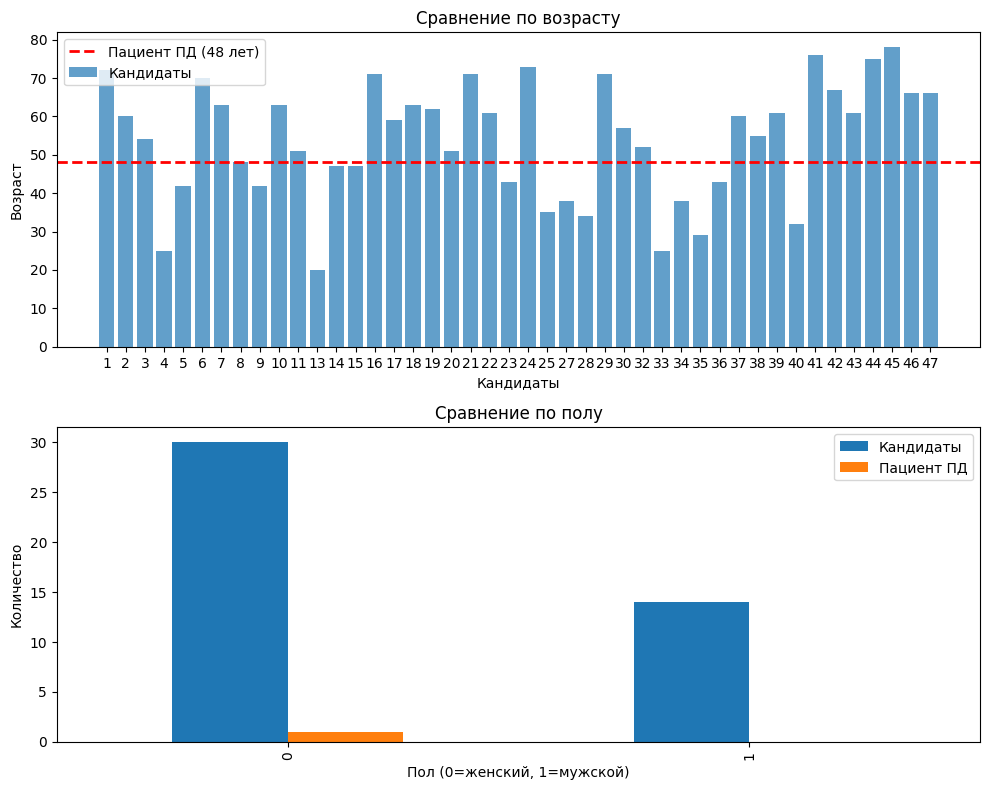

Сравнение возраста:
  Пациент ПД: 48 лет
  Кандидаты: средний 54.0 ± 15.4 лет
  Диапазон кандидатов: 20 - 78 лет
  Разница: 6.0 лет


In [26]:
# Визуализация сравнения (вертикальное расположение)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))  # 2 строки, 1 колонка

# 1. Сравнение по возрасту (верхний график)
ages = candidates['age'].dropna()
axes[0].bar(range(len(ages)), ages, alpha=0.7, label='Кандидаты')
axes[0].axhline(y=patient_pd['age'], color='red', linestyle='--', 
                linewidth=2, label=f'Пациент ПД ({patient_pd["age"]} лет)')
axes[0].set_xlabel('Кандидаты')
axes[0].set_ylabel('Возраст')
axes[0].set_title('Сравнение по возрасту')
axes[0].legend()
axes[0].set_xticks(range(len(ages)))
axes[0].set_xticklabels(candidates['patient_id'].str.replace('patient_ ', ''), rotation=0)

# 2. Распределение по полу (нижний график)
sex_counts = candidates['sex'].value_counts()
sex_counts_pd = pd.Series({patient_pd['sex']: 1})
sex_df = pd.DataFrame({
    'Кандидаты': sex_counts,
    'Пациент ПД': sex_counts_pd
}).fillna(0)

sex_df.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Пол (0=женский, 1=мужской)')
axes[1].set_ylabel('Количество')
axes[1].set_title('Сравнение по полу')
axes[1].legend()

plt.tight_layout()
plt.show()

# Статистика
print("Сравнение возраста:")
print(f"  Пациент ПД: {patient_pd['age']} лет")
print(f"  Кандидаты: средний {candidates['age'].mean():.1f} ± {candidates['age'].std():.1f} лет")
print(f"  Диапазон кандидатов: {candidates['age'].min()} - {candidates['age'].max()} лет")
print(f"  Разница: {abs(patient_pd['age'] - candidates['age'].mean()):.1f} лет")

In [27]:
# Колонки с ТМС-ответами
tms_columns = ['motor_evoked_right', 'motor_evoked_left', 
               'avg_avg_respone_right', 'avg_avg_respone_left']

# Данные для сравнения
comparison_data = []

for col in tms_columns:
    if col in candidates.columns and col in patient_pd.index:
        # Конвертируем строки с запятыми в числа
        pd_val = patient_pd[col]
        if isinstance(pd_val, str):
            pd_val = float(pd_val.replace(',', '.'))
        
        candidates_vals = []
        for val in candidates[col]:
            if isinstance(val, str):
                val = float(val.replace(',', '.'))
            if pd.notna(val):
                candidates_vals.append(val)
        
        if candidates_vals:
            comparison_data.append({
                'Показатель': col,
                'Пациент ПД': pd_val,
                'Кандидаты (mean)': np.mean(candidates_vals),
                'Кандидаты (std)': np.std(candidates_vals),
                'Кандидаты (n)': len(candidates_vals)
            })

comparison_df = pd.DataFrame(comparison_data)
print("Сравнение ТМС-показателей:")
print(comparison_df.to_string(index=False))

Сравнение ТМС-показателей:
           Показатель  Пациент ПД  Кандидаты (mean)  Кандидаты (std)  Кандидаты (n)
   motor_evoked_right    2.370000          2.518477         1.997686             44
    motor_evoked_left    0.508000          2.071023         1.468758             44
avg_avg_respone_right  170.228333         92.247268        41.341446             44
 avg_avg_respone_left  425.428333         99.557160        49.292202             44


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Пациент с Паркинсоном (patient_12)
patient_pd = df_candidates[df_candidates['patient_id'] == 'patient_ 12'].iloc[0]

# ТМС-колонки из списка
tms_columns = [
    'threshold_left', 'threshold_right', 
    'motor_evoked_right', 'motor_evoked_left',
    'theshold_edge_right', 'theshold_edge_left',
    'interstimul_threshod', 'inhibition_threshold_right',
    'avg_avg_respone_right', 'avg_avg_respone_left',
    'avg_interstimul_threshod', 'avg_inhibition_threshold_right',
    'avg_inhibition_threshold_left'
]

# Функция для конвертации строк с запятыми в числа
def convert_to_float(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        return float(value.replace(',', '.'))
    return float(value)

# Собираем данные для сравнения
comparison_results = []

for col in tms_columns:
    if col not in df_candidates.columns:
        print(f"Колонка {col} не найдена в данных")
        continue
    
    # Значение пациента с Паркинсоном
    pd_val = patient_pd[col]
    if pd.notna(pd_val):
        pd_val = convert_to_float(pd_val)
    else:
        print(f"У пациента нет данных по {col}")
        continue
    
    # Значения остальных кандидатов
    candidates_vals = []
    for idx, row in candidates.iterrows():
        val = row[col]
        if pd.notna(val):
            val = convert_to_float(val)
            candidates_vals.append(val)
    
    if len(candidates_vals) >= 2:  # Хотя бы 2 кандидата для сравнения
        mean_val = np.mean(candidates_vals)
        std_val = np.std(candidates_vals)
        z_score = (pd_val - mean_val) / std_val if std_val > 0 else 0
        percentile = stats.percentileofscore(candidates_vals, pd_val)
        
        comparison_results.append({
            'Показатель': col,
            'Пациент_ПД': pd_val,
            'Среднее_кандидатов': mean_val,
            'Std_кандидатов': std_val,
            'Z_score': z_score,
            'Процентиль': percentile,
            'N_кандидатов': len(candidates_vals),
            'Отличие': 'Значительное' if abs(z_score) > 2 else ('Умеренное' if abs(z_score) > 1 else 'В пределах нормы')
        })

# Создаем DataFrame с результатами
results_df = pd.DataFrame(comparison_results)
results_df = results_df.sort_values('Z_score', key=abs, ascending=False)

print("="*80)
print("СРАВНЕНИЕ ТМС-ПОКАЗАТЕЛЕЙ: Пациент с Паркинсоном vs Группа сравнения")
print("="*80)
print(results_df.to_string(index=False, float_format='%.3f'))

СРАВНЕНИЕ ТМС-ПОКАЗАТЕЛЕЙ: Пациент с Паркинсоном vs Группа сравнения
                    Показатель  Пациент_ПД  Среднее_кандидатов  Std_кандидатов  Z_score  Процентиль  N_кандидатов          Отличие
          avg_avg_respone_left     425.428              99.557          49.292    6.611     100.000            44     Значительное
         avg_avg_respone_right     170.228              92.247          41.341    1.886      90.909            44        Умеренное
           theshold_edge_right      61.000              44.705           9.638    1.691      95.455            44        Умеренное
          interstimul_threshod      61.000              44.705           9.638    1.691      95.455            44        Умеренное
      avg_interstimul_threshod      61.000              44.705           9.638    1.691      95.455            44        Умеренное
            theshold_edge_left      59.000              44.841           8.767    1.615      93.182            44        Умеренное
    inhibition

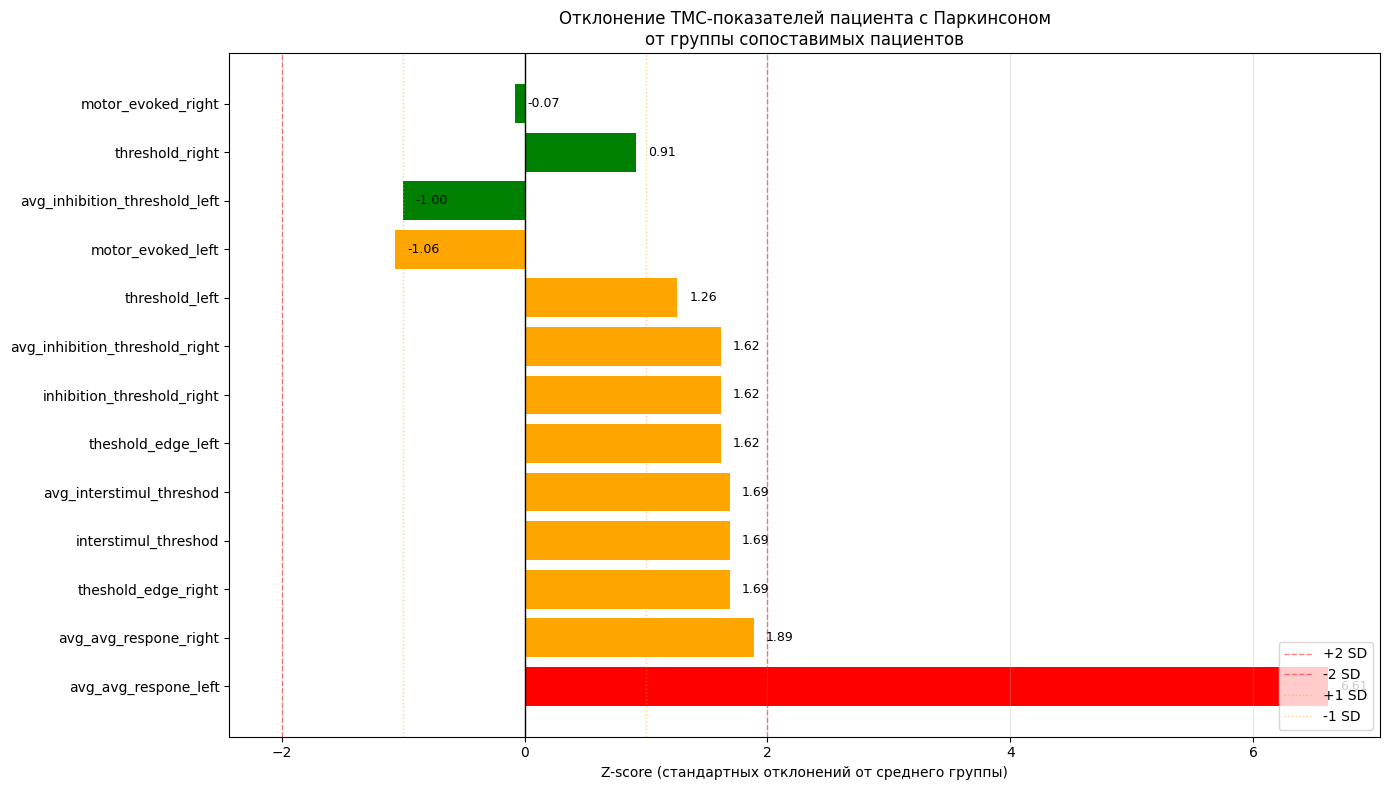

In [30]:
# Создаем наглядный график Z-scores
fig, ax = plt.subplots(figsize=(14, 8))

# Цветовая кодировка в зависимости от Z-score
colors = ['red' if abs(z) > 2 else 'orange' if abs(z) > 1 else 'green' for z in results_df['Z_score']]

bars = ax.barh(range(len(results_df)), results_df['Z_score'], color=colors)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='+2 SD')
ax.axvline(x=-2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='-2 SD')
ax.axvline(x=1, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='+1 SD')
ax.axvline(x=-1, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='-1 SD')

ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['Показатель'])
ax.set_xlabel('Z-score (стандартных отклонений от среднего группы)')
ax.set_title('Отклонение ТМС-показателей пациента с Паркинсоном\nот группы сопоставимых пациентов')

# Добавляем значения на бары
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.text(row['Z_score'] + 0.1, i, f"{row['Z_score']:.2f}", va='center', fontsize=9)

ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

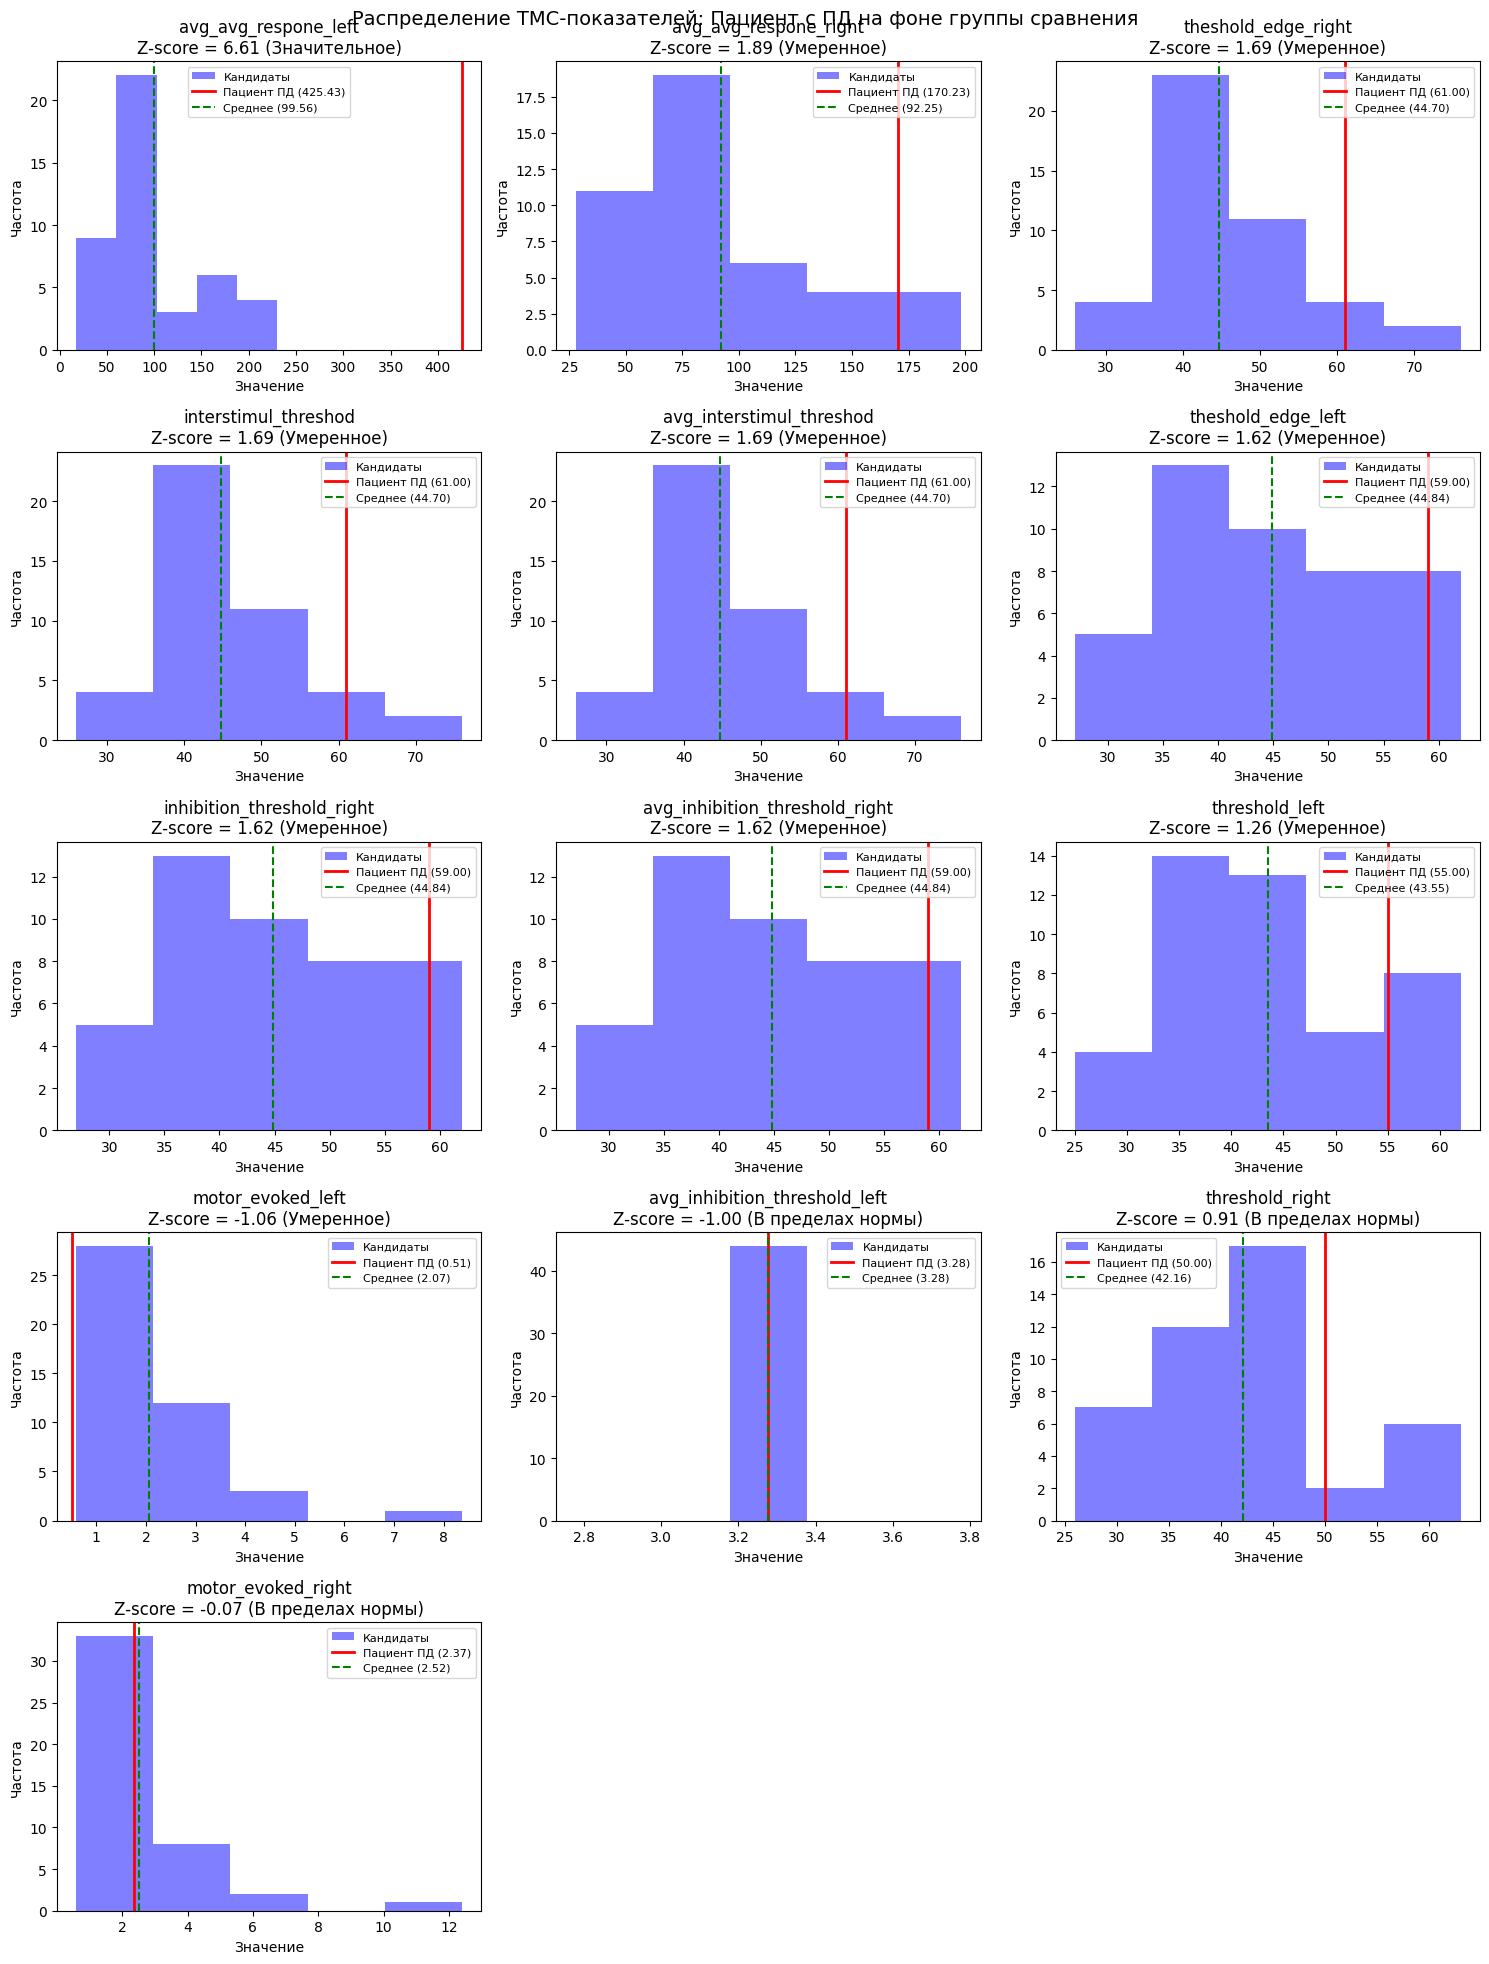

In [31]:
# Для каждого показателя показываем распределение
n_cols = 3
n_rows = (len(results_df) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, (_, row) in enumerate(results_df.iterrows()):
    if idx < len(axes):
        ax = axes[idx]
        
        # Собираем значения кандидатов для этого показателя
        col = row['Показатель']
        cand_vals = []
        for _, cand_row in candidates.iterrows():
            val = cand_row[col]
            if pd.notna(val):
                val = convert_to_float(val)
                cand_vals.append(val)
        
        if cand_vals:
            # Строим график
            ax.hist(cand_vals, bins=min(5, len(cand_vals)), alpha=0.5, color='blue', label='Кандидаты')
            ax.axvline(x=row['Пациент_ПД'], color='red', linewidth=2, label=f'Пациент ПД ({row["Пациент_ПД"]:.2f})')
            ax.axvline(x=row['Среднее_кандидатов'], color='green', linestyle='--', label=f'Среднее ({row["Среднее_кандидатов"]:.2f})')
            
            ax.set_title(f"{col}\nZ-score = {row['Z_score']:.2f} ({row['Отличие']})")
            ax.set_xlabel('Значение')
            ax.set_ylabel('Частота')
            ax.legend(fontsize=8)

# Убираем пустые подграфики
for idx in range(len(results_df), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Распределение ТМС-показателей: Пациент с ПД на фоне группы сравнения', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
print("\n" + "="*80)
print("СВОДНЫЙ АНАЛИЗ")
print("="*80)

# Подсчет показателей с разным уровнем отклонения
significant = results_df[abs(results_df['Z_score']) > 2]
moderate = results_df[(abs(results_df['Z_score']) > 1) & (abs(results_df['Z_score']) <= 2)]
normal = results_df[abs(results_df['Z_score']) <= 1]

print(f"\nИз {len(results_df)} проанализированных ТМС-показателей:")
print(f"  🔴 Значительное отличие (|Z| > 2): {len(significant)} показателей")
print(f"  🟠 Умеренное отличие (1 < |Z| ≤ 2): {len(moderate)} показателей")
print(f"  🟢 В пределах нормы (|Z| ≤ 1): {len(normal)} показателей")

if len(significant) > 0:
    print("\n🔴 ПОКАЗАТЕЛИ СО ЗНАЧИТЕЛЬНЫМ ОТЛИЧИЕМ:")
    for _, row in significant.iterrows():
        direction = "ВЫШЕ" if row['Z_score'] > 0 else "НИЖЕ"
        print(f"  • {row['Показатель']}: {direction} на {abs(row['Z_score']):.2f} SD")
        print(f"    (Пациент: {row['Пациент_ПД']:.3f} vs Группа: {row['Среднее_кандидатов']:.3f} ± {row['Std_кандидатов']:.3f})")

if len(significant) > 0:
    print("\n🟠 ПОКАЗАТЕЛИ СО СРЕДИНМ ОТЛИЧИЕМ:")
    for _, row in moderate.iterrows():
        direction = "ВЫШЕ" if row['Z_score'] > 0 else "НИЖЕ"
        print(f"  • {row['Показатель']}: {direction} на {abs(row['Z_score']):.2f} SD")
        print(f"    (Пациент: {row['Пациент_ПД']:.3f} vs Группа: {row['Среднее_кандидатов']:.3f} ± {row['Std_кандидатов']:.3f})")

# Вычисляем "профиль" пациента
mean_abs_z = results_df['Z_score'].abs().mean()
max_abs_z = results_df['Z_score'].abs().max()
pct_extreme = (len(significant) / len(results_df)) * 100

print(f"\n📊 ОБЩИЙ ПРОФИЛЬ ОТКЛОНЕНИЙ:")
print(f"  Средний |Z-score|: {mean_abs_z:.2f}")
print(f"  Максимальный |Z-score|: {max_abs_z:.2f}")
print(f"  Процент экстремальных показателей: {pct_extreme:.1f}%")


СВОДНЫЙ АНАЛИЗ

Из 13 проанализированных ТМС-показателей:
  🔴 Значительное отличие (|Z| > 2): 1 показателей
  🟠 Умеренное отличие (1 < |Z| ≤ 2): 9 показателей
  🟢 В пределах нормы (|Z| ≤ 1): 3 показателей

🔴 ПОКАЗАТЕЛИ СО ЗНАЧИТЕЛЬНЫМ ОТЛИЧИЕМ:
  • avg_avg_respone_left: ВЫШЕ на 6.61 SD
    (Пациент: 425.428 vs Группа: 99.557 ± 49.292)

🟠 ПОКАЗАТЕЛИ СО СРЕДИНМ ОТЛИЧИЕМ:
  • avg_avg_respone_right: ВЫШЕ на 1.89 SD
    (Пациент: 170.228 vs Группа: 92.247 ± 41.341)
  • theshold_edge_right: ВЫШЕ на 1.69 SD
    (Пациент: 61.000 vs Группа: 44.705 ± 9.638)
  • interstimul_threshod: ВЫШЕ на 1.69 SD
    (Пациент: 61.000 vs Группа: 44.705 ± 9.638)
  • avg_interstimul_threshod: ВЫШЕ на 1.69 SD
    (Пациент: 61.000 vs Группа: 44.705 ± 9.638)
  • theshold_edge_left: ВЫШЕ на 1.62 SD
    (Пациент: 59.000 vs Группа: 44.841 ± 8.767)
  • inhibition_threshold_right: ВЫШЕ на 1.62 SD
    (Пациент: 59.000 vs Группа: 44.841 ± 8.767)
  • avg_inhibition_threshold_right: ВЫШЕ на 1.62 SD
    (Пациент: 59.000 vs Г

Гипотеза:

avg_avg_respone_left / avg_avg_respone_right (right - т.к. вероятно может зависить от локации боли / повреждений от ПД - уточнить у специалиста!!!) - могут быть искомыми биомаркерами. Можно проверить на остальных пациентах, будут ли отличия от них тоже.

In [33]:
print("\n" + "="*80)
print("ИНТЕРПРЕТАЦИЯ ДЛЯ ГИПОТЕЗЫ О БИОМАРКЕРЕ ТМС-ОТВЕТА")
print("="*80)

if len(significant) >= 2:
    print("""
✅ СИЛЬНЫЙ АРГУМЕНТ В ПОЛЬЗУ ГИПОТЕЗЫ:
   Пациент с Паркинсоном демонстрирует значительные отличия 
   по нескольким ТМС-показателям на фоне сопоставимой группы.
   
   Это предположение, что ТМС-ответ может быть специфическим 
   для пациентов с Паркинсоном.
""")
elif len(significant) == 1:
    print("""
⚠️ УМЕРЕННЫЙ АРГУМЕНТ:
   Есть один показатель с значительным отличием, что может 
   указывать на потенциальный биомаркер, но требует подтверждения.
""")
else:
    print("""
❌ СЛАБЫЙ АРГУМЕНТ:
   Значительных отличий не обнаружено. ТМС-ответ пациента 
   не выходит за пределы вариабельности группы сравнения.
   
   Возможные причины:
   - Наличие Паркинсона не влияет на ТМС-ответ у этого конкретного пациента (?)
   - Группа сравнения недостаточно сопоставима
   - Нужна существенно большая выборка пациентов с Паркинсоном
""")

# Сохраняем результаты
results_df.to_csv('./results/tms_comparison_results.csv', index=False)


ИНТЕРПРЕТАЦИЯ ДЛЯ ГИПОТЕЗЫ О БИОМАРКЕРЕ ТМС-ОТВЕТА

⚠️ УМЕРЕННЫЙ АРГУМЕНТ:
   Есть один показатель с значительным отличием, что может 
   указывать на потенциальный биомаркер, но требует подтверждения.

